In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW, Adam
from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import StepLR,OneCycleLR
!pip install accelerate -U

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import numpy as np
import pandas as pd
import re
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
!pip install transformers
!pip install SentencePiece
!pip install git+https://github.com/PytorchLightning/pytorch-lightning.git@master --upgrade
#!pip install datasets
#from datasets import Dataset

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Cloning https://github.com/PytorchLightning/pytorch-lightning.git (to revision master) to /tmp/pip-req-build-k3vxq87a
  Running command git clone --filter=blob:none --quiet https://github.com/PytorchLightning/pytorch-lightning.git /tmp/pip-req-build-k3vxq87a
  Resolved https://github.com/PytorchLightning/pytorch-lightning.git to commit 6eae2310d6dae086596e5bdddd08e8cd3884336e
  Running command git submodule update --init --recursive -q
  Encountered 31 file(s) that should have been pointers, but weren't:
        .notebooks/course_UvA-DL/01-introduction-to-pytorch.ipynb
        .notebooks/course_UvA-DL/02-activation-functions.ipynb
        .notebooks/course_UvA-DL/03-initialization-and-optimiz

In [ ]:
import pytorch_lightning as pl
import transformers
from transformers import AlbertModel , AlbertTokenizerFast, AlbertTokenizer

In [ ]:
def create_parent_dir():
    '''
    Creates parent directory structures and return their values
    '''
    data_path = './content'
    archive_path = data_path + '/data/'
    if not os.path.exists(data_path):
        print(f"Did not find {data_path} directory, creating one...")
        os.mkdir(data_path)
        os.mkdir(archive_path)
    elif not os.path.exists(archive_path):
        os.mkdir(archive_path)
    else:
        print("Required Parent Directory structure already in place")
    return data_path,archive_path

In [ ]:
create_parent_dir()

Required Parent Directory structure already in place


('./content', './content/data/')

In [ ]:
!wget https://lp-prod-resources.s3.amazonaws.com/609/65187/2021-08-21-09-50-57/Khilnani_LP_hate_speech_data.csv

--2023-06-24 14:39:54--  https://lp-prod-resources.s3.amazonaws.com/609/65187/2021-08-21-09-50-57/Khilnani_LP_hate_speech_data.csv
Resolving lp-prod-resources.s3.amazonaws.com (lp-prod-resources.s3.amazonaws.com)... 52.92.161.25, 52.218.182.67, 52.92.153.65, ...
Connecting to lp-prod-resources.s3.amazonaws.com (lp-prod-resources.s3.amazonaws.com)|52.92.161.25|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 563781 (551K) [application/octet-stream]
Saving to: ‘Khilnani_LP_hate_speech_data.csv.1’

Khilnani_LP_hate_sp 100%[===================>] 550.57K  1.73MB/s    in 0.3s    

2023-06-24 14:39:55 (1.73 MB/s) - ‘Khilnani_LP_hate_speech_data.csv.1’ saved [563781/563781]



In [ ]:
!ls
with open("./Khilnani_LP_hate_speech_data.csv", "r") as f:
  for line in f.readlines():
    print(line)
    break

content				  Khilnani_LP_hate_speech_data.csv.1
Khilnani_LP_hate_speech_data.csv  sample_data
,tweet,class



In [ ]:
df_tw = pd.read_csv('./Khilnani_LP_hate_speech_data.csv')

In [ ]:
df_tw

,Unnamed: 0,tweet,class
0,0,!!! RT @mayasolovely: As a woman you shouldn't...,0
1,1,""" momma said no pussy cats inside my doghouse """,0
2,2,"""@Addicted2Guys: -SimplyAddictedToGuys http://...",0
3,3,"""@AllAboutManFeet: http://t.co/3gzUpfuMev"" woo...",0
4,4,"""@Allyhaaaaa: Lemmie eat a Oreo &amp; do these...",0
...,...,...,...
5588,5588,"you know what they say, the early bird gets th...",0
5589,5589,you're all niggers,1
5590,5590,you're such a retard i hope you get type 2 dia...,1
5591,5591,"you've gone and broke the wrong heart baby, an...",0


In [ ]:
df_tw.columns

Index(['Unnamed: 0', 'tweet', 'class'], dtype='object')

In [ ]:
df_tw.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
df_tw

,tweet,class
0,!!! RT @mayasolovely: As a woman you shouldn't...,0
1,""" momma said no pussy cats inside my doghouse """,0
2,"""@Addicted2Guys: -SimplyAddictedToGuys http://...",0
3,"""@AllAboutManFeet: http://t.co/3gzUpfuMev"" woo...",0
4,"""@Allyhaaaaa: Lemmie eat a Oreo &amp; do these...",0
...,...,...
5588,"you know what they say, the early bird gets th...",0
5589,you're all niggers,1
5590,you're such a retard i hope you get type 2 dia...,1
5591,"you've gone and broke the wrong heart baby, an...",0


In [ ]:
df_tw['tweet'] = df_tw['tweet'].apply(lambda x: re.sub(r"@\w*:?", "", x, 0, re.MULTILINE))

In [ ]:
df_tw

,tweet,class
0,!!! RT As a woman you shouldn't complain abou...,0
1,""" momma said no pussy cats inside my doghouse """,0
2,""" -SimplyAddictedToGuys http://t.co/1jL4hi8ZMF...",0
3,""" http://t.co/3gzUpfuMev"" woof woof and hot soles",0
4,""" Lemmie eat a Oreo &amp; do these dishes."" On...",0
...,...,...
5588,"you know what they say, the early bird gets th...",0
5589,you're all niggers,1
5590,you're such a retard i hope you get type 2 dia...,1
5591,"you've gone and broke the wrong heart baby, an...",0


In [ ]:
df_tw['tweet'].iloc[4]

'" Lemmie eat a Oreo &amp; do these dishes." One oreo? Lol'

In [ ]:
ckpt = 'albert-base-v2'
tokenizer = AlbertTokenizerFast.from_pretrained(ckpt)

In [ ]:
df_tw['tokenized'] = df_tw['tweet'].apply(lambda x: tokenizer(x, truncation=True, padding='max_length', max_length=64, return_tensors='pt'))

In [ ]:
df_tw['tokenized'].iloc[2]

{'input_ids': tensor([[    2,    13,     7,    13,     8,    18,  8983,   102,  1283, 16315,
            69,   262, 19979,    18,  7775,  6903,    38,     9,   716, 11698,
         22897,   300,  1822,   457,   380, 13235,     7,  4808,  1041,  4808,
          1041,  1047, 18957,   102,  8374,     3,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [ ]:
df_tw['tokenized'].iloc[2]['input_ids'].squeeze()

tensor([    2,    13,     7,    13,     8,    18,  8983,   102,  1283, 16315,
           69,   262, 19979,    18,  7775,  6903,    38,     9,   716, 11698,
        22897,   300,  1822,   457,   380, 13235,     7,  4808,  1041,  4808,
         1041,  1047, 18957,   102,  8374,     3,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df_tw['tokenized'], df_tw['class'], stratify=df_tw['class'], test_size=0.2, random_state=42)

In [ ]:
X_train.head(), X_train.iloc[0], y_train.iloc[0]

(2919    [input_ids, token_type_ids, attention_mask]
 5439    [input_ids, token_type_ids, attention_mask]
 5473    [input_ids, token_type_ids, attention_mask]
 1806    [input_ids, token_type_ids, attention_mask]
 1377    [input_ids, token_type_ids, attention_mask]
 Name: tokenized, dtype: object,
 {'input_ids': tensor([[    2,  1177,   333,  1177,    23, 10744,     3,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [ ]:
X_test.head(), X_test.iloc[0], y_test.iloc[0]

(649     [input_ids, token_type_ids, attention_mask]
 3132    [input_ids, token_type_ids, attention_mask]
 4997    [input_ids, token_type_ids, attention_mask]
 2829    [input_ids, token_type_ids, attention_mask]
 1260    [input_ids, token_type_ids, attention_mask]
 Name: tokenized, dtype: object,
 {'input_ids': tensor([[    2,  6643,  2218,    14,  6007,    71,   701,  9578,   154,    21,
          24702,  6643,    72,    99,    13, 27980,    58,     3,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [ ]:
class tweet_ds(Dataset):
  def __init__(self, tokens, labels):
    self.tokens = tokens
    self.labels = labels

  def __getitem__(self, idx):
    input_ids = self.tokens.iloc[idx]['input_ids'].squeeze()
    token_type_ids = self.tokens.iloc[idx]['token_type_ids'].squeeze()
    attention_mask = self.tokens.iloc[idx]['attention_mask'].squeeze()
    labels = torch.tensor(self.labels.iloc[idx]) #.type(torch.LongTensor)
    return input_ids, token_type_ids, attention_mask, labels

  def __len__(self):
    return len(self.labels)

In [ ]:
train_ds = tweet_ds(X_train, y_train)
test_ds  = tweet_ds(X_test, y_test)

In [ ]:
train_ds[0]

(tensor([    2,  1177,   333,  1177,    23, 10744,     3,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor(0))

In [ ]:
test_ds[0]

(tensor([    2,  6643,  2218,    14,  6007,    71,   701,  9578,   154,    21,
         24702,  6643,    72,    99,    13, 27980,    58,     3,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor(1))

In [ ]:
train_dl = DataLoader(dataset=train_ds, shuffle=True, batch_size=32, num_workers=os.cpu_count())
valid_dl = DataLoader(dataset=test_ds, shuffle=False, batch_size=32, num_workers=os.cpu_count())

In [ ]:
input_ids, token_type_ids, attention_mask, labels = next(iter(train_dl))

In [ ]:
input_ids.shape, token_type_ids.shape, attention_mask.shape, labels.shape

(torch.Size([32, 64]),
 torch.Size([32, 64]),
 torch.Size([32, 64]),
 torch.Size([32]))

In [ ]:
input_ids[0], token_type_ids[0], attention_mask[0], labels[0]

(tensor([    2,   279,  5910,  4075,  1323,    73,   619, 11720,    25, 14926,
          6448,  2838,  1569,  5910,  4075,  1941,    73,    50,    42, 13838,
            55,     3,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor(0))

In [ ]:
#help(model)

In [ ]:
input_ids, token_type_ids, attention_mask, labels = next(iter(valid_dl))

In [ ]:
input_ids.shape, token_type_ids.shape, attention_mask.shape, labels.shape

(torch.Size([32, 64]),
 torch.Size([32, 64]),
 torch.Size([32, 64]),
 torch.Size([32]))

In [ ]:
input_ids[0], token_type_ids[0], attention_mask[0], labels[0]

(tensor([    2,  6643,  2218,    14,  6007,    71,   701,  9578,   154,    21,
         24702,  6643,    72,    99,    13, 27980,    58,     3,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor(1))

In [ ]:
num_labels = 2

In [ ]:
class custom_albert(torch.nn.Module):
  def __init__(self, embed_size, ckpt, num_labels):
    super().__init__()

    self.checkpoint = ckpt
    self.basemodel = AlbertModel.from_pretrained(self.checkpoint)
    self.flatten = nn.Flatten()
    self.classifier = nn.Sequential(
        nn.Linear(embed_size, embed_size, bias=False),
        nn.BatchNorm1d(embed_size),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        #nn.Linear(512, 128, bias=False),
        #nn.BatchNorm1d(128),
        #nn.ReLU(inplace=True),
        #nn.Dropout(0.2),
        nn.Linear(embed_size, num_labels)
    )

  def forward(self,input_ids, token_type_ids, attention_mask):

    x = self.basemodel(input_ids=input_ids, token_type_ids=token_type_ids, attention_mask=attention_mask)
    x = self.flatten(x.last_hidden_state[:,0,:])
    x = self.classifier(x)

    return x

In [ ]:
model = custom_albert(768,ckpt,num_labels)

Some weights of the model checkpoint at albert-base-v2 were not used when initializing AlbertModel: ['predictions.decoder.bias', 'predictions.dense.weight', 'predictions.LayerNorm.weight', 'predictions.bias', 'predictions.LayerNorm.bias', 'predictions.dense.bias']
- This IS expected if you are initializing AlbertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing AlbertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
model

custom_albert(
  (basemodel): AlbertModel(
    (embeddings): AlbertEmbeddings(
      (word_embeddings): Embedding(30000, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0, inplace=False)
    )
    (encoder): AlbertTransformer(
      (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
      (albert_layer_groups): ModuleList(
        (0): AlbertLayerGroup(
          (albert_layers): ModuleList(
            (0): AlbertLayer(
              (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (attention): AlbertAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
   

In [ ]:
#Complete the training loop and validation loop and complete training cycle tomorrow. Take help from vision pipeline

In [ ]:
class Training():
    def __init__(self, model, optimizer, loss_fn, epochs, batch_size, train_gen, valid_gen, test_gen,
                len_train_ds, len_valid_ds, len_test_ds, device, labels_cat, oclr_sched=None, oclr=False, early_stop=True, patience=4):
        super().__init__()
        self.model = model.to(device)
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.train_generator = train_gen
        self.valid_generator = valid_gen
        self.test_generator = test_gen
        self.train_ds_size = len_train_ds
        self.valid_ds_size = len_valid_ds
        self.test_ds_size = len_test_ds
        self.train_history = {'loss': [], 'accuracy': [], 'f1': [], 'precision': [], 'recall': []}
        self.valid_history = {'loss': [], 'accuracy': [], 'f1': [], 'precision': [], 'recall': [], 'ckpt_name': []}
        self.early_stop_enabled = early_stop
        self.patience_level = patience
        self.device = device
        self.classes = labels_cat
        self.oclr = oclr
        if(self.oclr):
          self.oclr_sched = oclr_sched

    def train_step(self, input_ids, token_type_ids, attention_mask, train_label):
        self.model.train()
        output = self.model(input_ids, token_type_ids, attention_mask)
        loss_value = self.loss_fn(output, train_label)
        self.optimizer.zero_grad()
        loss_value.backward()
        self.optimizer.step()
        if(self.oclr):
          self.oclr_sched.step()
        return output, loss_value  ## To be updated

    def test_step(self, input_ids, token_type_ids, attention_mask, validation_label):
        self.model.eval()
        with torch.inference_mode():
            val_output = self.model(input_ids, token_type_ids, attention_mask)
            loss_value = self.loss_fn(val_output, validation_label)
        return val_output, loss_value ## To be updated



    def train(self, df):
        ds_len = self.train_ds_size
        gen = self.train_generator
        loss_epoch = 0
        accuracy = 0
        avg_epoch_loss = 0
        avg_accuracy = 0

        for input_ids, token_type_ids, attention_mask, y_batch in gen:
            y_batch = y_batch.type(torch.LongTensor)
            input_ids, token_type_ids, attention_mask, y_batch = input_ids.to(self.device), token_type_ids.to(self.device), attention_mask.to(self.device), y_batch.to(self.device)
            output, loss_value = self.train_step(input_ids, token_type_ids, attention_mask, y_batch)

            pred_labls = list(np.argmax(output.detach().cpu().numpy(), axis=1))
            temp_df = pd.DataFrame({'orig_label': list(y_batch.detach().cpu().numpy()), 'pred_label': pred_labls})
            df = pd.concat([df, temp_df])
            loss_epoch += loss_value.item()*y_batch.shape[0]
            accuracy += (np.array(pred_labls) == y_batch.detach().cpu().numpy()).sum().item()

        avg_epoch_loss = loss_epoch/ds_len
        avg_accuracy = accuracy/ds_len

        return df, avg_epoch_loss, avg_accuracy

    def test_validate(self,df,valid=True,train=False):
        if(valid):
            ds_len = self.valid_ds_size
            gen = self.valid_generator
        elif(train):
            ds_len = self.train_ds_size
            gen = self.train_generator
        else:
            ds_len = self.test_ds_size
            gen = self.test_generator
        loss_epoch = 0
        accuracy = 0
        avg_epoch_loss = 0
        avg_accuracy = 0

        for input_ids, token_type_ids, attention_mask, y_batch in gen:
            y_batch = y_batch.type(torch.LongTensor)
            input_ids, token_type_ids, attention_mask, y_batch = input_ids.to(self.device), token_type_ids.to(self.device), attention_mask.to(self.device), y_batch.to(self.device)
            output, loss_value = self.test_step(input_ids, token_type_ids, attention_mask, y_batch)

            pred_labls = list(np.argmax(output.detach().cpu().numpy(), axis=1))
            temp_df = pd.DataFrame({'orig_label': list(y_batch.detach().cpu().numpy()), 'pred_label': pred_labls})
            df = pd.concat([df, temp_df])
            loss_epoch += loss_value.item()*y_batch.shape[0]
            accuracy += (np.array(pred_labls) == y_batch.detach().cpu().numpy()).sum().item()
            #accuracy += (pred_labls == y_batch).sum().item()

        avg_epoch_loss = loss_epoch/ds_len
        avg_accuracy = accuracy/ds_len

        return df, avg_epoch_loss, avg_accuracy

    def train_model(self):
        for epoch in range(self.epochs):
            start_time = time.time()
            histdf_train = pd.DataFrame({'orig_label': [], 'pred_label': []})
            histdf_val   = pd.DataFrame({'orig_label': [], 'pred_label': []})
            df_train_cm, avg_epoch_train_loss, train_accuracy = self.train(histdf_train)
            df_val_cm, avg_epoch_val_loss, val_accuracy = self.test_validate(histdf_val)

            ##################################################################################
            #Following Code snippets calculate and update metric values
            ##################################################################################

            acc_class_train = self.update_metrics_on_epoch_end(df_train_cm, True, self.train_history, avg_epoch_train_loss, train_accuracy)
            acc_class_valid = self.update_metrics_on_epoch_end(df_val_cm, False, self.valid_history, avg_epoch_val_loss, val_accuracy)

            #Code for earlystopping ####
            la = self.valid_history['accuracy']
            if(self.early_stop_enabled):
                if (len(la) > 10):
                    exit_train_loop = self.early_stopping(self.patience_level)
                    if(exit_train_loop):
                        return self.train_history, self.valid_history

            ##Code for saving checkpoints
            if ((la[-1] >= 0.7) and (len(la) > 1)):
                if(la[-1] > max(la[0:-1])):
                    self.save_checkpoint(epoch, la[-1])
            elif ((la[-1] >= 0.7) and (len(la) == 1)):
                self.save_checkpoint(epoch, la[-1])
            torch.cuda.empty_cache()
            print(f'Epoch : {epoch}, Train Loss: {avg_epoch_train_loss}, Train Accuracy: {train_accuracy},\n Validation Loss: {avg_epoch_val_loss}, Validation Accuracy: {val_accuracy}')
            print(f'Time taken: {np.round((time.time() - start_time), 4)}')

        print(f'Training completed successfully. Loading best checkpoint weights ...')
        if len(self.valid_history['ckpt_name']) > 0:
            self.model.load_state_dict(torch.load(self.valid_history['ckpt_name'][-1]))
            print(f'Best checkpoint weights loaded : {self.valid_history["ckpt_name"][-1]}')
        else:
            print("Ouch !! seems like you dont have any checkpoints saved matching criteria specified in logic. Please excuse !")

        return acc_class_train, acc_class_valid


    def update_metrics_on_epoch_end(self, df_cm, train, ds_dict, loss, accuracy):
        f1, precision, recall, recall_list = self.calc_rec_prec_f1(df_cm, train) #Move this to line above once f1 logic is fixed
        ds_dict['loss'].append(loss)
        ds_dict['accuracy'].append(accuracy)
        ds_dict['f1'].append(f1)
        ds_dict['precision'].append(precision)
        ds_dict['recall'].append(recall)
        return recall_list

    def calc_rec_prec_f1(self, df, train):
        print_string = "Training Confusion Matrix" if train else "Validation Confusion Matrix"
        cm = confusion_matrix(df['orig_label'], df['pred_label'])
        print(f'{print_string} \n {cm}')
        num_class = cm.shape[0]
        if (num_class>2):
            incorrect_pred_list = [i for i in range(num_class)]
            recall_list = [i for i in range(num_class)]
            prec_list = [i for i in range(num_class)]
            total_cm = np.sum(cm)
            class_weight_list = [np.sum(cm[i])/total_cm for i in range(num_class)]
            ### Code for recall
            for i in range(num_class):
                recall = cm[i,i]/np.sum(cm[i])
                recall_list[i] = recall

            ## Code for incorrect predictions
            for i in range(num_class):
                val_in = [k for k in range(num_class)]
                val_in.remove(i)
                incorrect_pred = 0
                for j in val_in:
                    incorrect_pred += cm[i,j]
                    incorrect_pred_list[i] = incorrect_pred

            ## Code for precision
            for i in range(num_class):
                val_in = [k for k in range(num_class)]
                val_in.remove(i)
                total_incorrect_preds=0
                for j in val_in:
                    total_incorrect_preds += incorrect_pred_list[j]
                    prec_list[i] = cm[i,i]/(total_incorrect_preds+cm[i,i])

            ## code for cum precision
            precision =np.sum(np.array(prec_list)*np.array(class_weight_list))
            #Code for cum recall
            recall = np.sum(np.array(recall_list)*np.array(class_weight_list))
            ## Code for F1
            ##f1 = 2*precision*recall/(precision+recall)

        else:
            tn, fp, fn, tp = confusion_matrix(df['orig_label'], df['pred_label']).ravel()
            precision = tp/(tp+fp)
            recall = tp/(tp+fn)
            f1 = 2*precision*recall/(precision+recall)
            recall_list = None
        f1 = 2*precision*recall/(precision+recall)
        return f1, precision, recall, recall_list

    def early_stopping(self, early_stop_level):
        la = self.valid_history['accuracy']
        exit_train_loop = False
        n = -1
        while n > -(early_stop_level):
            if not (la[n] <= la[n-1]):
                break
            n = n-1
        if abs(n) == early_stop_level:
            print("Validation accuracy has not improved over last 4 epochs, hence invoking early stopping and exiting training process")
            if len(self.valid_history['ckpt_name']) > 0:
                print('Loading Best weights..')
                self.model.load_state_dict(torch.load(self.valid_history['ckpt_name'][-1]))
            else:
                print("Ouch !! seems like you dont have any checkpoints saved matching criteria specified in logic. Please excuse !")
            exit_train_loop = True
        return exit_train_loop

    def save_checkpoint(self, epoch, acc):
        ckpt_path = './content/data/ckpt/'
        if not os.path.exists(ckpt_path):
            os.mkdir(ckpt_path)
        ckpt_name = ckpt_path + 'ckpt_' + "Epoch_" + str(epoch) + "_Acc_" + str(acc) + '.pt'
        torch.save(self.model.state_dict(), ckpt_name)
        self.valid_history['ckpt_name'].append(ckpt_name)
        print(f'Saved Checkpoint : {ckpt_name}')

    def get_test_accuracy(self):
        df = pd.DataFrame({'orig_label': [], 'pred_label': []})
        df_test, avg_test_loss, test_accuracy = self.test_validate(df,False)
        print(f'Test Loss: {avg_test_loss}, Test Accuracy: {test_accuracy}')
        return df_test, avg_test_loss, test_accuracy

    def predict_single(self, image, transforms=True):
        #In case of dicom images, custom function should be defined outside this class and called with training_object.model
        if(transforms):
            image = Image.open(image)
            image = self.test_transforms(image)
        image = torch.unsqueeze(image, dim=0)
        image = image.to(self.device)
        output = self.model(image)
        pred_label = int(np.argmax(output.detach().cpu().numpy(), axis=1))
        print(f'Predicted label for image supplied is : {self.classes[pred_label]}')
        return self.classes[pred_label]

    def pred_image_show(self,images, labels):
        fig, subs = plt.subplots(3,3, figsize=(14,12))
        for i, sub in enumerate(subs.flatten()):
            pred_class = self.predict_single(images[i], False)
            img_array = images[i].numpy()
            img_array[0] = (img_array[0]*self.std[0]+self.mean[0])*255
            img_array[1] = (img_array[1]*self.std[1]+self.mean[1])*255
            img_array[2] = (img_array[2]*self.std[2]+self.mean[2])*255
            img_array = np.transpose(img_array, (1,2,0))
            img_array = Image.fromarray(np.uint8(img_array)).convert('RGB')
            sub.imshow(img_array) #, cmap='gray')
            sub.set_title(f'{pred_class}(Pred) : {self.classes[labels[i]]}(Orig)')

    def plot_metrics(self):
        list = ['accuracy', 'loss', 'f1', 'recall', 'precision']
        for metrics in list:
            x = [i for i in range(len(self.train_history[metrics]))]
            y1 = self.train_history[metrics]
            y2 = self.valid_history[metrics]
            fig, ax = plt.subplots()
            ax.plot(x, y1, label="train_"+metrics)
            ax.plot(x, y2, label="valid_"+metrics)
            plt.suptitle(f'Plot showing {metrics} for Different Epoch Runs')
            ax.legend()
            plt.show()

    def plot_accuracy(self, acc_class_train, acc_class_valid):
        df_train_acc = pd.DataFrame({'class': self.classes, 'accuracy':acc_class_train})
        df_train_acc['train_valid'] = 'train'
        df_valid_acc = pd.DataFrame({'class': self.classes, 'accuracy':acc_class_valid})
        df_valid_acc['train_valid'] = 'valid'
        df_combined = pd.concat([df_train_acc, df_valid_acc], axis=0)
        sns.barplot(data=df_combined, x='class', y='accuracy', hue='train_valid', order=self.classes)
        plt.show()

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
model = custom_albert(768,ckpt,num_labels)
optimizer = Adam(model.parameters(), lr=0.00002)
loss_fn = CrossEntropyLoss()
epochs = 10
batch_size = 32
train_gen = train_dl
valid_gen = valid_dl
test_gen = None
len_train_ds = len(train_ds)
len_valid_ds = len(test_ds)
len_test_ds = 0
device = 'cuda' if torch.cuda.is_available() else 'cpu'
labels_cat = ['NON-FAKE', 'FAKE']


Some weights of the model checkpoint at albert-base-v2 were not used when initializing AlbertModel: ['predictions.decoder.bias', 'predictions.dense.weight', 'predictions.LayerNorm.weight', 'predictions.bias', 'predictions.LayerNorm.bias', 'predictions.dense.bias']
- This IS expected if you are initializing AlbertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing AlbertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
train_obj = Training(model, optimizer, loss_fn, epochs, batch_size, train_gen, valid_gen, test_gen,
                     len_train_ds, len_valid_ds, len_test_ds, device, labels_cat)

In [ ]:
train_obj.__dict__

{'model': custom_albert(
   (basemodel): AlbertModel(
     (embeddings): AlbertEmbeddings(
       (word_embeddings): Embedding(30000, 128, padding_idx=0)
       (position_embeddings): Embedding(512, 128)
       (token_type_embeddings): Embedding(2, 128)
       (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
       (dropout): Dropout(p=0, inplace=False)
     )
     (encoder): AlbertTransformer(
       (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
       (albert_layer_groups): ModuleList(
         (0): AlbertLayerGroup(
           (albert_layers): ModuleList(
             (0): AlbertLayer(
               (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
               (attention): AlbertAttention(
                 (query): Linear(in_features=768, out_features=768, bias=True)
                 (key): Linear(in_features=768, out_features=768, bias=True)
                 (value): Linear(in_features=768, out

In [ ]:
 train_acc, valid_acc = train_obj.train_model()

Training Confusion Matrix 
 [[2868  462]
 [ 304  840]]
Validation Confusion Matrix 
 [[799  34]
 [ 55 231]]
Saved Checkpoint : ./content/data/ckpt/ckpt_Epoch_0_Acc_0.9204647006255585.pt
Epoch : 0, Train Loss: 0.3716800693933805, Train Accuracy: 0.8287885561019223,
 Validation Loss: 0.24153162401845352, Validation Accuracy: 0.9204647006255585
Time taken: 52.6371
Training Confusion Matrix 
 [[3221  109]
 [ 195  949]]
Validation Confusion Matrix 
 [[824   9]
 [ 81 205]]
Epoch : 1, Train Loss: 0.18244670804425123, Train Accuracy: 0.9320518551631649,
 Validation Loss: 0.20592531029191583, Validation Accuracy: 0.9195710455764075
Time taken: 53.8426
Training Confusion Matrix 
 [[3263   67]
 [ 131 1013]]
Validation Confusion Matrix 
 [[815  18]
 [ 53 233]]
Saved Checkpoint : ./content/data/ckpt/ckpt_Epoch_2_Acc_0.936550491510277.pt
Epoch : 2, Train Loss: 0.1256639084074718, Train Accuracy: 0.9557443004023245,
 Validation Loss: 0.17908587359338066, Validation Accuracy: 0.936550491510277
Time ta

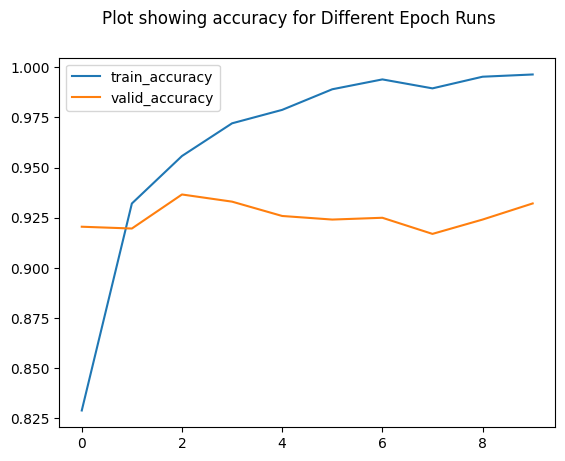

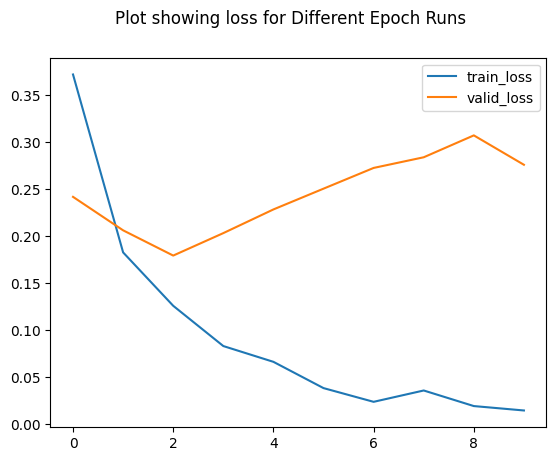

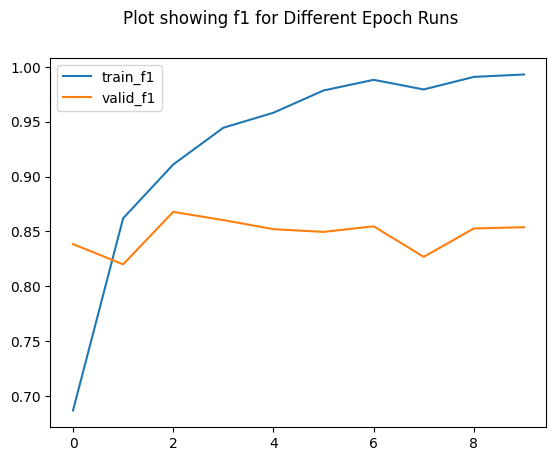

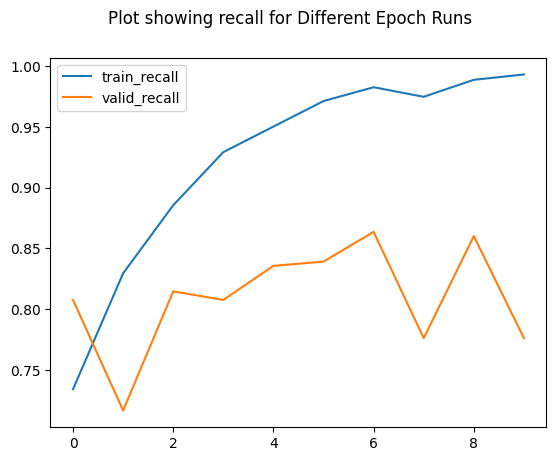

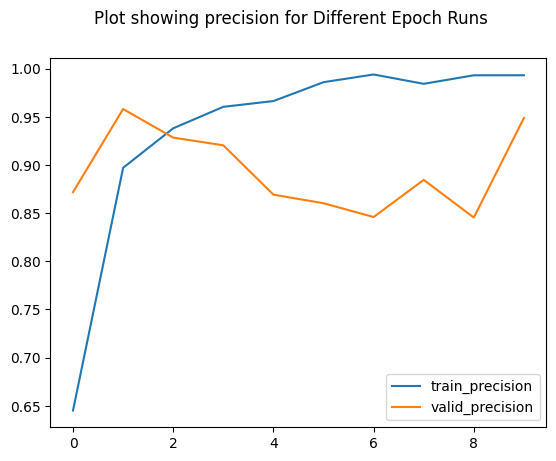

In [ ]:
train_obj.plot_metrics()